# Ejercicio 2 — Cálculo de Itô y martingalas

**Máster Executive en Finanzas Cuantitativas 2026 · AFI Global Education**  
**Asignatura:** Fundamentos matemáticos — Procesos estocásticos

---

## Objetivo

1. determinar el drift que convierte el cociente $X_t/N_t$ en martingala;
2. resolver una integral de Itô mediante la dinámica de $W_t^3$;
3. demostrar que un cuadrado compensado es martingala, obtener su ley y verificarla por simulación.

Se distingue en todo momento entre una identidad analítica, una aproximación temporal de una integral de Itô y el error puramente Monte Carlo.


## Configuración del entorno


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
from scipy.stats import chi2, kstest
from IPython.display import display

plt.rcParams.update({
    "figure.dpi": 110,
    "font.size": 13,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "legend.frameon": False,
    "legend.fontsize": 10,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "axes.prop_cycle": plt.cycler(color=["#001391", "#1973b8", "#5e9cc9"]),
    "axes.grid": True,
    "grid.alpha": 0.15,
    "axes.titleweight": "bold",
})

OUT = Path("../output/ejercicio-2")
OUT.mkdir(parents=True, exist_ok=True)
T = 1.0
print("Horizonte de las comprobaciones numéricas: T = 1 año")


Horizonte de las comprobaciones numéricas: T = 1 año


## 2.a — Elegir la deriva para que el cociente sea martingala

Dados

$$dX_t=\mu X_t\,dt+\sigma X_t\,dW_t^{(1)},\qquad
dN_t=\frac12N_t\,dt+N_t\,dW_t^{(2)},$$

con $d\langle W^{(1)},W^{(2)}\rangle_t=\rho\,dt$, buscamos $\mu$ para que $Y_t=X_t/N_t$ sea martingala. $\sigma$ es la volatilidad de $X$; $\rho\in[-1,1]$ mide la correlación entre los ruidos.

**Idea.** El cociente debe quedar sin deriva, pero no basta restar las derivas de $X$ y $N$: la curvatura del cociente y la correlación generan correcciones de Itô. Después comprobaremos que la martingala es verdadera, no solo local.

Tomamos valores iniciales deterministas, $N_0>0$ y $X_0\ne0$. Como $N_t=N_0e^{W_t^{(2)}}>0$, podemos dividir. Si $X_0=0$, el cociente es cero y cualquier $\mu$ sirve.

### Aplicar Itô al cociente

Para $h(x,n)=x/n$,

$$h_x=\frac1n,\quad h_n=-\frac{x}{n^2},\quad
h_{xx}=0,\quad h_{nn}=\frac{2x}{n^3},\quad h_{xn}=-\frac1{n^2}.$$

La notación $\langle X,N\rangle$ representa la covariación cuadrática. Itô da

$$dY_t=h_x\,dX_t+h_n\,dN_t
+\frac12h_{nn}\,d\langle N\rangle_t
+h_{xn}\,d\langle X,N\rangle_t.$$

El término con $h_{xx}$ es cero. El término cruzado no lleva $1/2$: suma las dos contribuciones simétricas. Sustituimos cada parte:

$$h_x\,dX_t=\mu Y_t\,dt+\sigma Y_t\,dW_t^{(1)},$$

$$h_n\,dN_t=-\frac12Y_t\,dt-Y_t\,dW_t^{(2)}.$$

Como $d\langle N\rangle_t=N_t^2dt$, la curvatura de $1/n$ añade

$$\frac12h_{nn}\,d\langle N\rangle_t
=\frac12\frac{2X_t}{N_t^3}N_t^2dt=Y_t\,dt.$$

La correlación aporta $d\langle X,N\rangle_t=\sigma\rho X_tN_tdt$ y, por tanto,

$$h_{xn}\,d\langle X,N\rangle_t=-\sigma\rho Y_t\,dt.$$

Agrupando,

$$dY_t=Y_t\left[\left(\mu+\frac12-\sigma\rho\right)dt
+\sigma\,dW_t^{(1)}-dW_t^{(2)}\right].$$

Anular la deriva exige

$$\boxed{\mu=\sigma\rho-\frac12}.$$

### Por qué es una martingala verdadera

Sea $q=\sigma^2+1-2\sigma\rho\ge0$, la tasa de varianza del ruido combinado. Con el valor anterior de $\mu$,

$$Y_t=Y_0\exp\left(\sigma W_t^{(1)}-W_t^{(2)}-\frac12qt\right).$$

Entre $s$ y $t$, el incremento del ruido es independiente de $\mathcal F_s$ —la información disponible hasta $s$— y normal de varianza $q(t-s)$. La esperanza de su exponencial es $e^{q(t-s)/2}$, exactamente compensada por el término negativo. Así,

$$E[|Y_t|]=|Y_0|<\infty,\qquad E[Y_t\mid\mathcal F_s]=Y_s.$$

Si $q=0$, el ruido se cancela y $Y_t=Y_0$.

**Qué muestra la gráfica.** Usamos $\sigma=0.30$, $\rho=0.40$ y $Y_0=1$ como ejemplo, no como datos del enunciado. Arriba, cada trayectoria fluctúa; abajo, la media se compara con uno. La banda es un intervalo Monte Carlo puntual del 95 %, no una banda que deba contener todas las fechas simultáneamente.


Ejemplo: sigma=0.30, rho=0.40
mu = sigma*rho - 1/2 = -0.3800
q = sigma² + 1 - 2*sigma*rho = 0.8500
Máximo desvío de E[Y_t]=Y_0 en unidades de SE: 2.09


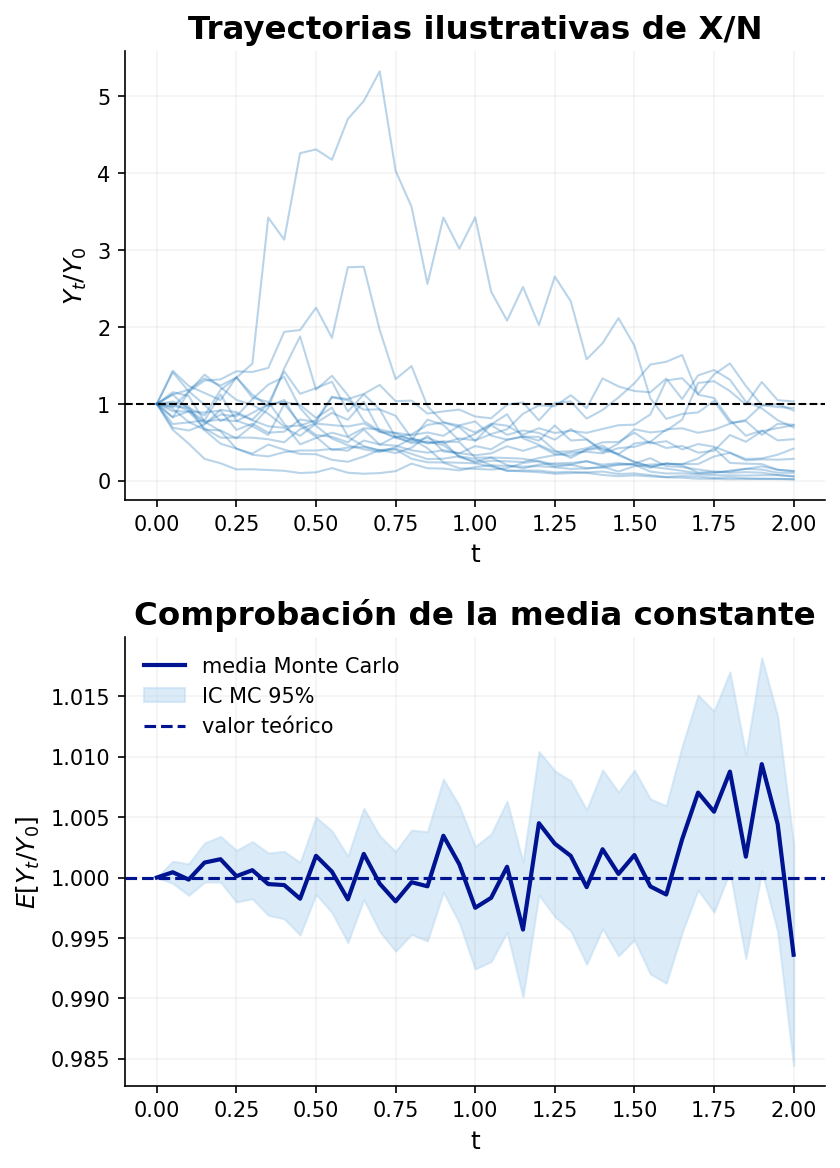

In [2]:
# Comprobación numérica ilustrativa; sigma y rho no están fijados en el enunciado.
sigma_demo = 0.30
rho_demo = 0.40
mu_demo = sigma_demo * rho_demo - 0.50
q_demo = sigma_demo**2 + 1.0 - 2.0 * sigma_demo * rho_demo
assert q_demo >= 0.0

t_grid = np.linspace(0.0, 2.0, 41)
n_mc = 200_000
rng = np.random.default_rng(20260201)
z = rng.standard_normal((n_mc, len(t_grid) - 1))
y_marginal = np.ones((n_mc, len(t_grid)))
y_marginal[:, 1:] = np.exp(
    -0.5 * q_demo * t_grid[1:]
    + np.sqrt(q_demo * t_grid[1:]) * z
)
media_mc = y_marginal.mean(axis=0)
se_mc = y_marginal.std(axis=0, ddof=1) / np.sqrt(n_mc)
z_media = np.divide(
    media_mc - 1.0, se_mc,
    out=np.zeros_like(media_mc), where=se_mc > 0,
)
assert np.max(np.abs(z_media)) < 5.5

# Trayectorias coherentes temporalmente del browniano efectivo.
n_paths_plot = 16
rng_paths = np.random.default_rng(20260202)
dt = t_grid[1] - t_grid[0]
B = np.c_[np.zeros(n_paths_plot),
          np.cumsum(np.sqrt(dt) * rng_paths.standard_normal(
              (n_paths_plot, len(t_grid) - 1)), axis=1)]
y_paths = np.exp(-0.5 * q_demo * t_grid + np.sqrt(q_demo) * B)

print(f"Ejemplo: sigma={sigma_demo:.2f}, rho={rho_demo:.2f}")
print(f"mu = sigma*rho - 1/2 = {mu_demo:.4f}")
print(f"q = sigma² + 1 - 2*sigma*rho = {q_demo:.4f}")
print(f"Máximo desvío de E[Y_t]=Y_0 en unidades de SE: "
      f"{np.max(np.abs(z_media)):.2f}")

fig, axes = plt.subplots(2, 1, figsize=(5.8, 8.0))
axes[0].plot(t_grid, y_paths.T, color="#1973b8", alpha=0.30, lw=1)
axes[0].axhline(1.0, color="black", ls="--", lw=1)
axes[0].set(title="Trayectorias ilustrativas de X/N",
            xlabel="t", ylabel="$Y_t/Y_0$")

axes[1].plot(t_grid, media_mc, color="#001391", lw=2, label="media Monte Carlo")
axes[1].fill_between(t_grid, media_mc - 1.96*se_mc, media_mc + 1.96*se_mc,
                     color="#b9d9f2", alpha=0.5, label="IC MC 95%")
axes[1].axhline(1.0, color="#001391", ls="--", lw=1.5,
                label="valor teórico")
axes[1].set(title="Comprobación de la media constante",
            xlabel="t", ylabel="$E[Y_t/Y_0]$")
axes[1].legend()
fig.tight_layout()
fig.savefig(OUT / "grafico_2a_cociente_martingala.png",
            dpi=150, bbox_inches="tight")
plt.show()


## 2.b — Resolver una integral buscando su dinámica

Queremos expresar, para un browniano con $W_0=0$,

$$I_t=\int_0^t(W_s^2-s)\,dW_s.$$

**Idea.** La pista $W_t^3$ funciona porque su derivada contiene $W_t^2$. Separaremos la integral y combinaremos Itô con la regla del producto:

$$I_t=\int_0^tW_s^2\,dW_s-\int_0^ts\,dW_s.$$

### Itô para la primera parte

Con $f(w)=w^3/3$, $f'(w)=w^2$ y $f''(w)=2w$,

$$d\left(\frac{W_t^3}{3}\right)=W_t^2\,dW_t+W_t\,dt.$$

El segundo término es la corrección de Itô. Despejar e integrar da

$$\int_0^tW_s^2\,dW_s=\frac{W_t^3}{3}-\int_0^tW_s\,ds.$$

### Regla del producto para la segunda

El tiempo tiene variación finita, luego $d\langle t,W\rangle_t=0$. Por eso,

$$d(tW_t)=W_t\,dt+t\,dW_t,$$

$$\int_0^ts\,dW_s=tW_t-\int_0^tW_s\,ds.$$

Al restar, las dos integrales ordinarias de $W_s$ se cancelan:

$$\boxed{I_t=\frac{W_t^3}{3}-tW_t}.$$

La comprobación es directa: el diferencial del resultado es $(W_t^2-t)dW_t$ y su valor inicial es cero.

### Qué comprueba la simulación

De $E[W_s^2]=s$ y $E[W_s^4]=3s^2$ obtenemos
$E[(W_s^2-s)^2]=2s^2$. La isometría de Itô da

$$E[I_t]=0,\qquad\operatorname{Var}(I_t)=\int_0^t2s^2\,ds=\frac{2t^3}{3}.$$

El código evalúa el integrando **antes** del siguiente incremento: son sumas por la izquierda. La gráfica compara esa aproximación con la expresión exacta sobre una misma trayectoria. El segundo panel muestra cómo disminuye el RMSE —raíz del error cuadrático medio— al reducir el paso $\Delta t$. Hay error de discretización en la suma, no en la identidad.


In [3]:
def error_integral_ito(n_steps, n_paths=40_000, seed=0):
    '''Aproxima la integral con sumas de Itô por la izquierda.'''
    dt = T / n_steps
    rng = np.random.default_rng(seed)
    W = np.zeros(n_paths)
    I_riemann = np.zeros(n_paths)
    for j in range(n_steps):
        s = j * dt
        dW = np.sqrt(dt) * rng.standard_normal(n_paths)
        I_riemann += (W**2 - s) * dW
        W += dW
    I_cerrada = W**3 / 3.0 - T * W
    diferencia = I_riemann - I_cerrada
    return {
        "Pasos": n_steps,
        "dt": dt,
        "RMSE identidad": np.sqrt(np.mean(diferencia**2)),
        "Sesgo identidad": diferencia.mean(),
        "Media I cerrada": I_cerrada.mean(),
        "Varianza I cerrada": I_cerrada.var(ddof=1),
    }

tabla_conv = pd.DataFrame([
    error_integral_ito(50, seed=2050),
    error_integral_ito(200, seed=2200),
    error_integral_ito(800, seed=2800),
]).set_index("Pasos")

assert np.all(np.diff(tabla_conv["RMSE identidad"].values) < 0)
assert abs(tabla_conv.loc[800, "Varianza I cerrada"] - 2/3) < 0.03

display(tabla_conv.style.format({
    "dt": "{:.5f}", "RMSE identidad": "{:.6f}",
    "Sesgo identidad": "{:+.6f}", "Media I cerrada": "{:+.6f}",
    "Varianza I cerrada": "{:.6f}",
}))
print(f"Varianza teórica en t=1: {2/3:.6f}")


Varianza teórica en t=1: 0.666667


,dt,RMSE identidad,Sesgo identidad,Media I cerrada,Varianza I cerrada
Pasos,,,,,
50,0.02000,0.140808,+0.000344,-0.000841,0.650274
200,0.00500,0.070856,-0.000082,+0.002658,0.643326
800,0.00125,0.035489,-0.000333,+0.004753,0.651426


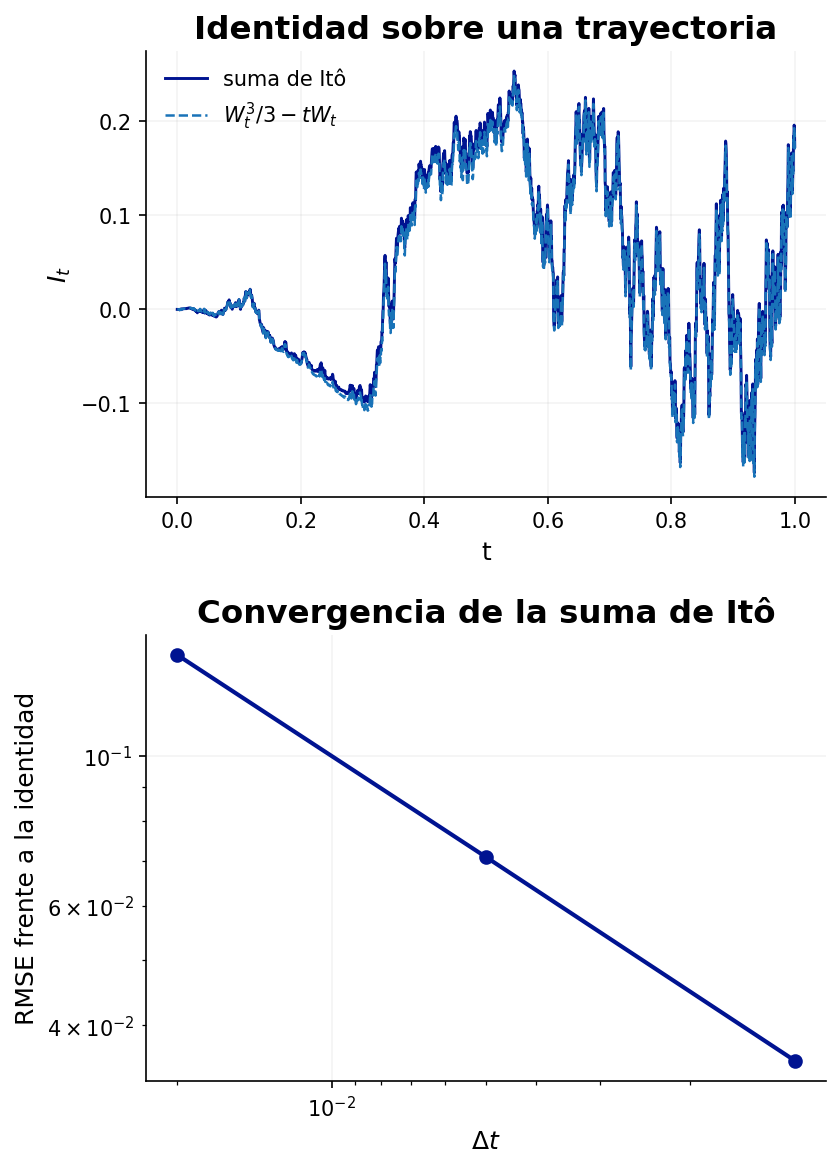

In [4]:
# Una trayectoria: suma de Itô frente a la expresión cerrada en todo el intervalo.
n_steps = 2_000
dt = T / n_steps
rng = np.random.default_rng(20260203)
W = 0.0
I_sum = 0.0
trayectoria_W = [0.0]
trayectoria_sum = [0.0]
trayectoria_cerrada = [0.0]
for j in range(n_steps):
    s = j * dt
    dW = np.sqrt(dt) * rng.standard_normal()
    I_sum += (W**2 - s) * dW
    W += dW
    t_now = (j + 1) * dt
    trayectoria_W.append(W)
    trayectoria_sum.append(I_sum)
    trayectoria_cerrada.append(W**3/3.0 - t_now*W)

fig, axes = plt.subplots(2, 1, figsize=(5.8, 8.0))
tiempos = np.linspace(0, T, n_steps + 1)
axes[0].plot(tiempos, trayectoria_sum, lw=1.4, label="suma de Itô")
axes[0].plot(tiempos, trayectoria_cerrada, lw=1.2, ls="--",
             label="$W_t^3/3-tW_t$")
axes[0].set(title="Identidad sobre una trayectoria", xlabel="t", ylabel="$I_t$")
axes[0].legend()

axes[1].loglog(tabla_conv["dt"], tabla_conv["RMSE identidad"],
               marker="o", lw=2, color="#001391")
axes[1].invert_xaxis()
axes[1].set(title="Convergencia de la suma de Itô",
            xlabel="$\\Delta t$", ylabel="RMSE frente a la identidad")
fig.tight_layout()
fig.savefig(OUT / "grafico_2b_integral_ito.png", dpi=150, bbox_inches="tight")
plt.show()


---

## Apartado 2.c.1 — Por qué compensamos el cuadrado y cómo probar que es martingala

**Qué pide el enunciado.** Para el proceso

$$M_t=\left(\int_0^t s\,dW_s\right)^2-\frac{t^3}{3},$$

describir dos maneras de probar que es martingala y elegir una para desarrollar. Usaremos Itô como demostración principal y dejaremos la esperanza condicional como una comprobación alternativa breve.

### 1. Antes de demostrar: ¿por qué restamos $t^3/3$?

Llamamos

$$A_t=\int_0^t s\,dW_s.$$

Esta integral de Itô es una martingala centrada: $E[A_t]=0$. Como el integrando $s$ es determinista, $A_t$ también es gaussiano. Sin embargo, media cero no significa dispersión constante: su varianza crece con el tiempo. La isometría de Itô permite cuantificar ese crecimiento:

$$E[A_t^2]=\operatorname{Var}(A_t)=\int_0^t s^2\,ds=\frac{t^3}{3}.$$

Por eso $A_t^2$ ya no es una martingala: su esperanza aumenta, mientras que una martingala integrable conserva su esperanza. El proceso del enunciado tiene una intención concreta:

$$M_t=A_t^2-\frac{t^3}{3}.$$

Es el cuadrado de $A_t$ al que le quitamos exactamente su crecimiento esperado. Esto explica la construcción, pero tener esperanza cero no basta para demostrar que es martingala; a continuación comprobaremos su dinámica.

Ahora introducimos la notación que resume esa compensación:

$$q_t:=\frac{t^3}{3}=E[A_t^2]=\langle A\rangle_t.$$

Aquí la variación cuadrática $\langle A\rangle_t$ es determinista y coincide con la varianza de $A_t$: acumula el cuadrado del coeficiente que multiplica a $dW_t$. La idea que verificaremos es:

$$\boxed{A_t^2\text{ adquiere deriva}\ \Rightarrow
A_t^2-\langle A\rangle_t\text{ elimina esa deriva}}.$$

### 2. Método principal: Itô muestra la cancelación

Partimos de $dA_t=t\,dW_t$. Para $f(a)=a^2$, tenemos $f'(a)=2a$ y $f''(a)=2$. La fórmula de Itô da

$$d(A_t^2)=2A_t\,dA_t+d\langle A\rangle_t.$$

Como $d\langle A\rangle_t=t^2\,dt$, al sustituir resulta

$$d(A_t^2)=2tA_t\,dW_t+t^2\,dt.$$

El cuadrado ha incorporado la deriva $t^2\,dt$. Por otro lado,

$$d\left(\frac{t^3}{3}\right)=t^2\,dt.$$

Al restar ambas dinámicas,

$$dM_t=(2tA_t\,dW_t+t^2\,dt)-t^2\,dt,$$

$$\boxed{dM_t=2tA_t\,dW_t}.$$

El término $t^3/3$ está construido exactamente para cancelar el $t^2\,dt$ que aparece al cuadrar la martingala $A_t$.

**De martingala local a martingala verdadera.** Como $M_0=0$,

$$M_t=\int_0^t2sA_s\,dW_s.$$

Para poder afirmar que esta integral es una martingala verdadera, comprobamos que su integrando tiene segundo momento integrable en cualquier horizonte finito $T$:

$$E\left[\int_0^T(2sA_s)^2\,ds\right]
=4\int_0^Ts^2E[A_s^2]\,ds,$$

$$4\int_0^Ts^2\frac{s^3}{3}\,ds
=\frac43\int_0^Ts^5\,ds=\frac{2T^6}{9}<\infty.$$

El integrando es adaptado y continuo. Esta cota garantiza que $M_t$ es una martingala cuadrado integrable, no solo una martingala local sin deriva.

#### Método alternativo: esperanza condicional

Para $0\le s<t$, separamos el pasado del incremento futuro:

$$A_t=A_s+\int_s^t u\,dW_u.$$

El incremento es independiente de la información $\mathcal F_s$, tiene esperanza condicionada cero y varianza $\int_s^tu^2\,du=(t^3-s^3)/3$. Al desarrollar el cuadrado, el término cruzado desaparece al condicionar y queda

$$E[A_t^2\mid\mathcal F_s]=A_s^2+\frac{t^3-s^3}{3}.$$

El aumento de varianza queda exactamente compensado al restar $t^3/3$:

$$E[M_t\mid\mathcal F_s]
=A_s^2+\frac{t^3-s^3}{3}-\frac{t^3}{3}
=A_s^2-\frac{s^3}{3}=M_s.$$

La integrabilidad también se ve directamente: $E[|M_t|]\le E[A_t^2]+q_t=2q_t<\infty$. Ambas vías explican la misma compensación: Itô elimina la deriva y la esperanza condicional elimina el crecimiento esperado desde $s$ hasta $t$.


## Apartado 2.c.2 — Del cuadrado de una normal a la distribución de $M_t$

**Qué pide el enunciado.** Identificar la ley de $M_t$ y calcular su esperanza y varianza. La demostración anterior explica cómo evoluciona; ahora miramos su distribución en una fecha fija.

### 1. Transformar la distribución que ya conocemos

Sabemos que $A_t\sim N(0,t^3/3)$. Para $t>0$, su ley puede escribirse con una normal estándar $Z\sim N(0,1)$:

$$A_t\overset d=\sqrt{\frac{t^3}{3}}\,Z.$$

Al elevar al cuadrado, la raíz desaparece:

$$A_t^2\overset d=\frac{t^3}{3}Z^2.$$

Como $Z^2$ sigue una chi-cuadrado con un grado de libertad, escribimos $U=Z^2\sim\chi_1^2$. Restar la compensación da

$$\boxed{M_t\overset d=\frac{t^3}{3}(U-1),\qquad U\sim\chi_1^2}.$$

La distribución de $M_t$ no es normal: estamos tomando el cuadrado de una normal y desplazándolo para que tenga media cero. Es asimétrica, con cola hacia valores positivos y soporte $[-t^3/3,\infty)$, porque $U\ge0$. En $t=0$, $M_0=0$ con probabilidad uno.

El símbolo $\overset d=$ significa igualdad en distribución en esa fecha; no autoriza a compartir una sola $Z$ entre todas las fechas para simular una trayectoria.

### 2. Leer la media y la varianza a partir de la transformación

La chi-cuadrado anterior tiene $E[U]=1$ y $\operatorname{Var}(U)=2$, pues $E[Z^2]=1$ y $E[Z^4]=3$. Usando $q_t=t^3/3$,

$$E[M_t]=q_t(E[U]-1)=0.$$

Restar una constante no cambia la varianza; multiplicar por $q_t$ la multiplica por $q_t^2$:

$$\operatorname{Var}(M_t)=q_t^2\operatorname{Var}(U)
=2q_t^2=\frac{2t^6}{9}.$$

Así, la compensación conserva la media en cero, pero no impide que la dispersión de $M_t$ crezca. Su varianza coincide con la cota calculada por isometría en la demostración anterior.

### 3. Referencia para la comprobación en $t=1$

$$M_1\overset d=\frac{U-1}{3},\qquad U\sim\chi_1^2,$$

$$E[M_1]=0,\qquad\operatorname{Var}(M_1)=\frac29\approx0.222222,$$

$$M_1\ge-\frac13.$$

Para comparar la forma completa, la distribución acumulada es

$$P(M_t\le m)=F_{\chi_1^2}\left(1+\frac{m}{q_t}\right),
\qquad m\ge-q_t,\quad t>0,$$

y vale cero para $m<-q_t$. En $t=1$, el argumento se simplifica a $3m+1$. Estas son las referencias para el Excel: media, varianza, forma y soporte. El código siguiente añade un contraste con 500.000 réplicas, distinto de las 5.000 guardadas en el libro.


### Leer la distribución simulada

El histograma muestra la asimetría y el borde inferior −1/3; la densidad teórica crece sin límite al acercarse a ese borde. El segundo panel compara probabilidades acumuladas, una comprobación menos sensible al ancho de las barras. Se representa hasta el percentil 99,5 % para no comprimir la zona central; la cola continúa más allá.


E[M1] teórica = 0; simulada = -0.000153 (SE=0.000665)
V[M1] teórica = 0.222222; simulada = 0.221344
KS tras deshacer escala/desplazamiento: D=0.0008, p=0.9292


,Teórico,Simulado
Probabilidad,,
0.010000,-0.333281,-0.333279
0.050000,-0.332023,-0.332027
0.500000,-0.181688,-0.181422
0.950000,+0.947153,+0.946370
0.990000,+1.878299,+1.878501


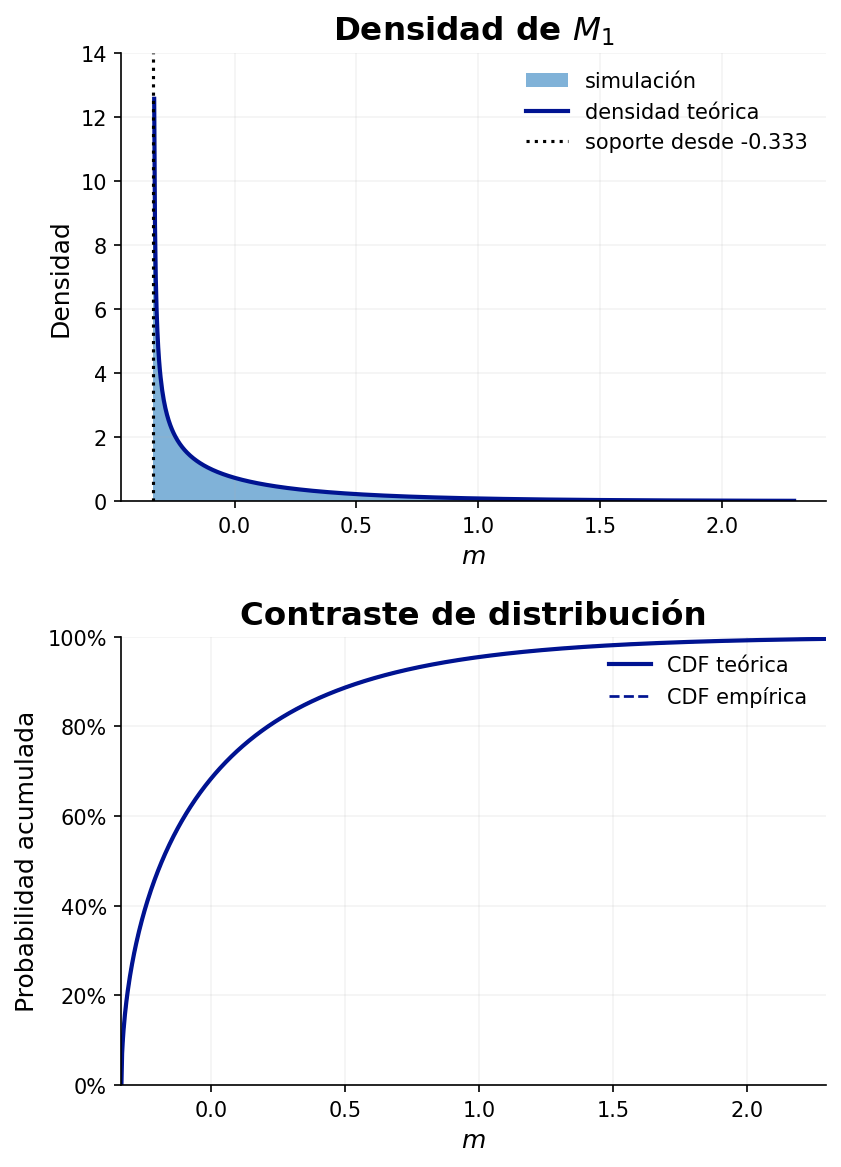

In [5]:
N_TERMINAL = 500_000
rng = np.random.default_rng(20260204)
q1 = T**3 / 3.0
Z = rng.standard_normal(N_TERMINAL)
M1 = q1 * (Z**2 - 1.0)

media_emp = M1.mean()
var_emp = M1.var(ddof=1)
se_media = M1.std(ddof=1) / np.sqrt(N_TERMINAL)
transformada_chi2 = M1 / q1 + 1.0
ks = kstest(transformada_chi2, "chi2", args=(1,))

niveles = np.array([0.01, 0.05, 0.50, 0.95, 0.99])
cuantiles = pd.DataFrame({
    "Teórico": q1 * (chi2.ppf(niveles, 1) - 1.0),
    "Simulado": np.quantile(M1, niveles),
}, index=niveles)
cuantiles.index.name = "Probabilidad"

assert abs(media_emp) < 4.0 * se_media
assert abs(var_emp - 2/9) / (2/9) < 0.015
assert M1.min() >= -q1 - 1e-14

print(f"E[M1] teórica = 0; simulada = {media_emp:+.6f} "
      f"(SE={se_media:.6f})")
print(f"V[M1] teórica = {2/9:.6f}; simulada = {var_emp:.6f}")
print(f"KS tras deshacer escala/desplazamiento: "
      f"D={ks.statistic:.4f}, p={ks.pvalue:.4f}")
display(cuantiles.style.format("{:+.6f}"))

m_max = np.quantile(M1, 0.995)
# La densidad diverge de forma integrable en -q. Se inicia la curva
# ligeramente a la derecha para no aplastar la región informativa.
m_grid = np.linspace(-q1 + 0.003, m_max, 800)
densidad = chi2.pdf(m_grid / q1 + 1.0, 1) / q1

fig, axes = plt.subplots(2, 1, figsize=(5.8, 8.0))
axes[0].hist(M1, bins=220, density=True, alpha=0.55, color="#1973b8",
             range=(-q1, m_max), label="simulación")
axes[0].plot(m_grid, densidad, color="#001391", lw=2,
             label="densidad teórica")
axes[0].axvline(-q1, color="black", ls=":", lw=1.5,
                label=f"soporte desde {-q1:.3f}")
axes[0].set(title="Densidad de $M_1$",
            xlabel="$m$", ylabel="Densidad", ylim=(0, 14))
axes[0].legend()

m_cdf = np.linspace(-q1, m_max, 1_000)
cdf_teorica = chi2.cdf(m_cdf/q1 + 1.0, 1)
ordenada = np.sort(M1)
idx = np.linspace(0, len(ordenada)-1, 2_000, dtype=int)
cdf_empirica = (idx + 1) / len(ordenada)
axes[1].plot(m_cdf, cdf_teorica, color="#001391", lw=2,
             label="CDF teórica")
axes[1].plot(ordenada[idx], cdf_empirica, color="#001391", lw=1.3,
             ls="--", label="CDF empírica")
axes[1].set(title="Contraste de distribución",
            xlabel="$m$", ylabel="Probabilidad acumulada",
            xlim=(-q1, m_max), ylim=(0, 1))
axes[1].yaxis.set_major_formatter(PercentFormatter(1))
axes[1].legend()

fig.tight_layout()
fig.savefig(OUT / "grafico_2c_distribucion_M1.png", dpi=150, bbox_inches="tight")
plt.show()


## 2.c.3 — Simular la trayectoria y comprobar la ley en Excel

Son dos preguntas distintas: **una trayectoria** muestra la evolución temporal; **muchas réplicas en $t=1$** permiten contrastar media, varianza, forma y soporte. El archivo entregado es [ejercicio2_simulacion_Mt.xlsx](../output/ejercicio-2/ejercicio2_simulacion_Mt.xlsx).

### Una trayectoria, paso a paso

En la malla $t_j=j/100$, los incrementos de la integral interior son independientes y normales:

$$\Delta A_j=\sqrt{\Delta q_j}\,Z_j,\qquad
\Delta q_j=\frac{t_j^3-t_{j-1}^3}{3},\qquad Z_j\sim N(0,1).$$

Desde $A_0=M_0=0$, actualizamos

$$A_{t_j}=A_{t_{j-1}}+\Delta A_j,\qquad
M_{t_j}=A_{t_j}^2-\frac{t_j^3}{3}.$$

Usamos la varianza integrada exacta: no hay error de Euler en las fechas de la malla. Cada intervalo necesita su propia normal.

La hoja **Trayectoria** contiene tiempo, varianza acumulada, incremento de varianza, normal, incremento de $A$, $A$ y $M$. Las operaciones esenciales en Excel son:

| Operación | Fórmula equivalente |
|---|---|
| Normal estándar | NORM.S.INV(RAND()) |
| Incremento de A | SQRT(incremento_varianza)*normal |
| Acumular A | A_anterior+incremento_A |
| Calcular M | A_actual^2-tiempo^3/3 |

Los nombres son los de Excel en inglés; se adaptan a la configuración regional. Las normales del libro están guardadas como valores para conservar la muestra al recalcular.

### Muchas réplicas en una fecha

Para $t=1$ basta generar normales independientes y transformar

$$M_1^{(k)}=\frac{(Z^{(k)})^2-1}{3}.$$

**Replica_t1** guarda 5.000 réplicas. **Resumen** compara su media con cero y su varianza muestral con $2/9$. En Excel se usan AVERAGE y VAR.S; el error estándar de la media es $s_M/\sqrt n$, con $s_M$ la desviación típica muestral y $n=5000$.

Un intervalo aproximado del 95 % es $\overline M\pm1.96\,s_M/\sqrt n$. Las diferencias pequeñas respecto a la teoría son error de muestreo; ninguna observación puede ser menor que $-1/3$. La acumulada teórica es $F_{\chi_1^2}(3m+1)$ para $m\ge-1/3$.

**Comprobación del archivo entregado.** La siguiente celda lee sus 5.000 observaciones, sin generar otras. La tabla y la gráfica contrastan exactamente la muestra del Excel, distinta de las 500.000 réplicas del apartado anterior.


IC 95 % aproximado para la media: [-0.004874; 0.021398]


,Teoría,Excel
Media,0.000000,0.008262
Varianza,0.222222,0.224584
Cota / mínimo observado,-0.333333,-0.333333


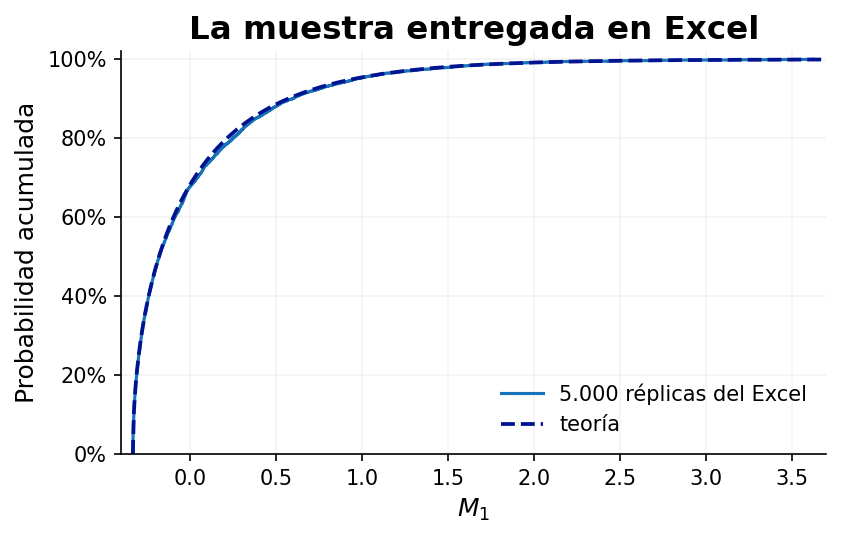

In [6]:
# Reutilizar las observaciones del Excel: no se simula una muestra nueva.
from openpyxl import load_workbook

libro_m = load_workbook(OUT / "ejercicio2_simulacion_Mt.xlsx", data_only=True)
hoja_m = libro_m["Replica_t1"]
z_excel = np.array([hoja_m.cell(i, 2).value for i in range(3, 5003)])
m_excel = np.array([hoja_m.cell(i, 4).value for i in range(3, 5003)])
libro_m.close()
assert np.allclose(m_excel, (z_excel**2 - 1)/3, atol=1e-14)
assert m_excel.min() >= -1/3
media_excel = m_excel.mean()
var_excel = m_excel.var(ddof=1)
se_excel = np.sqrt(var_excel / len(m_excel))
tabla_excel = pd.DataFrame({
    "Teoría": [0, 2/9, -1/3],
    "Excel": [media_excel, var_excel, m_excel.min()],
}, index=["Media", "Varianza", "Cota / mínimo observado"])
display(tabla_excel.style.format("{:.6f}"))
print(f"IC 95 % aproximado para la media: [{media_excel-1.96*se_excel:.6f}; "
      f"{media_excel+1.96*se_excel:.6f}]")
fig, ax = plt.subplots(figsize=(5.8, 3.8))
m_ordenado = np.sort(m_excel)
ax.step(m_ordenado, np.arange(1, len(m_excel)+1)/len(m_excel),
        where="post", color="#1973b8", lw=1.5, label="5.000 réplicas del Excel")
m_teoria = np.linspace(-1/3, 3.7, 700)
ax.plot(m_teoria, chi2.cdf(3*m_teoria+1, 1), color="#001391",
        ls="--", lw=1.8, label="teoría")
ax.set(title="La muestra entregada en Excel", xlabel="$M_1$",
       ylabel="Probabilidad acumulada", xlim=(-0.4, 3.7), ylim=(0, 1.02))
ax.yaxis.set_major_formatter(PercentFormatter(1))
ax.legend()
fig.tight_layout()
fig.savefig(OUT / "grafico_2c_excel_M1.png", dpi=150, bbox_inches="tight")
plt.show()


### Evolución temporal y contraste condicional

La siguiente simulación acumula incrementos independientes de A. Se muestran 18 trayectorias y la media de 100.000, con intervalos Monte Carlo puntuales del 95 %. Un camino no tiene que quedarse cerca de cero: la propiedad de martingala se refiere a la esperanza condicional, no a la suavidad de cada trayectoria.

Como diagnóstico adicional, agrupamos 400.000 pares entre $s=0.5$ y $t=1$ por el valor inicial de $M_s$. El incremento medio de cada grupo debería ser compatible con cero. Este contraste respalda la demostración; no la sustituye.


In [7]:
n_steps = 100
n_ensemble = 100_000
n_show = 18
tiempos = np.linspace(0.0, 1.0, n_steps + 1)
q_grid = tiempos**3 / 3.0
dq = np.diff(q_grid)
rng = np.random.default_rng(20260205)

A = np.zeros(n_ensemble)
media_M = np.zeros(n_steps + 1)
se_M = np.zeros(n_steps + 1)
paths_M = np.zeros((n_show, n_steps + 1))
for j in range(1, n_steps + 1):
    A += np.sqrt(dq[j-1]) * rng.standard_normal(n_ensemble)
    M = A**2 - q_grid[j]
    media_M[j] = M.mean()
    se_M[j] = M.std(ddof=1) / np.sqrt(n_ensemble)
    paths_M[:, j] = M[:n_show]

# Contraste condicional entre s=0.5 y t=1.
N_COND = 400_000
s = 0.5
qs, qt = s**3/3.0, 1.0/3.0
rng_cond = np.random.default_rng(20260206)
A_s = np.sqrt(qs) * rng_cond.standard_normal(N_COND)
A_t = A_s + np.sqrt(qt-qs) * rng_cond.standard_normal(N_COND)
M_s = A_s**2 - qs
M_t = A_t**2 - qt
incremento = M_t - M_s

Xreg = np.column_stack([np.ones(N_COND), M_s])
intercepto, pendiente = np.linalg.lstsq(Xreg, M_t, rcond=None)[0]
grupos = pd.qcut(M_s, 5, labels=False)
tabla_cond = pd.DataFrame({
    "M_s": M_s, "Incremento": incremento, "Grupo": grupos
}).groupby("Grupo").agg(
    M_s_medio=("M_s", "mean"),
    incremento_medio=("Incremento", "mean"),
    n=("Incremento", "size"),
    sd=("Incremento", "std"),
)
tabla_cond["SE incremento"] = tabla_cond["sd"] / np.sqrt(tabla_cond["n"])
tabla_cond["z"] = tabla_cond["incremento_medio"] / tabla_cond["SE incremento"]

assert abs(intercepto) < 0.01
assert abs(pendiente - 1.0) < 0.03
assert np.max(np.abs(tabla_cond["z"])) < 4.0

print(f"Regresión empírica M_t = alfa + beta M_s: "
      f"alfa={intercepto:+.5f}, beta={pendiente:.5f}")
print("Incremento medio por quintil de M_s (debe ser 0):")
display(tabla_cond.style.format({
    "M_s_medio": "{:+.5f}", "incremento_medio": "{:+.5f}",
    "SE incremento": "{:.5f}", "z": "{:+.2f}", "sd": "{:.5f}",
}))


Regresión empírica M_t = alfa + beta M_s: alfa=-0.00056, beta=1.00149
Incremento medio por quintil de M_s (debe ser 0):


,M_s_medio,incremento_medio,n,sd,SE incremento,z
Grupo,,,,,,
0,-0.04078,+0.00088,80000,0.41434,0.00146,+0.60
1,-0.03522,+0.00092,80000,0.42806,0.00151,+0.61
2,-0.02227,-0.00304,80000,0.43133,0.00152,-1.99
3,+0.00447,-0.00240,80000,0.47158,0.00167,-1.44
4,+0.09354,+0.00086,80000,0.57542,0.00203,+0.42


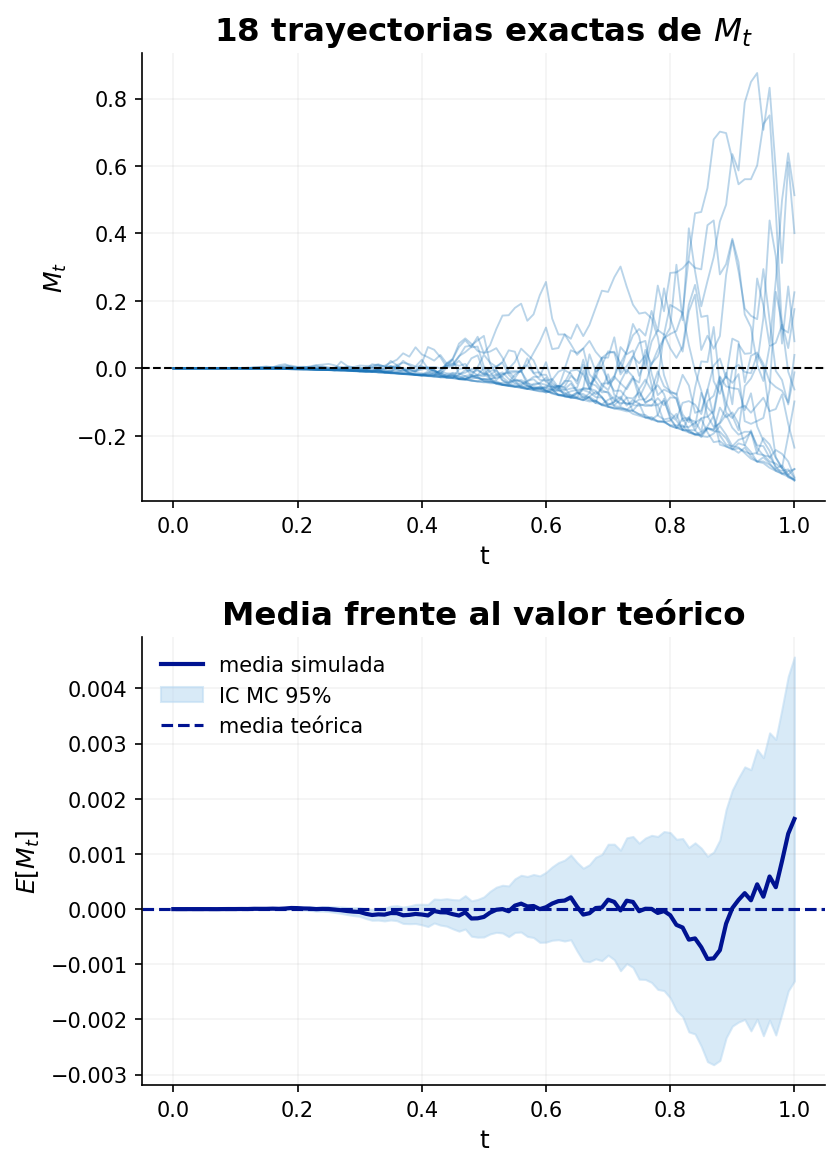

In [8]:
fig, axes = plt.subplots(2, 1, figsize=(5.8, 8.0))
axes[0].plot(tiempos, paths_M.T, color="#1973b8", alpha=0.30, lw=0.9)
axes[0].axhline(0.0, color="black", ls="--", lw=1)
axes[0].set(title="18 trayectorias exactas de $M_t$",
            xlabel="t", ylabel="$M_t$")

axes[1].plot(tiempos, media_M, color="#001391", lw=2,
             label="media simulada")
axes[1].fill_between(tiempos, media_M-1.96*se_M, media_M+1.96*se_M,
                     color="#b9d9f2", alpha=0.55, label="IC MC 95%")
axes[1].axhline(0.0, color="#001391", ls="--", lw=1.5,
                label="media teórica")
axes[1].set(title="Media frente al valor teórico",
            xlabel="t", ylabel="$E[M_t]$")
axes[1].legend()
fig.tight_layout()
fig.savefig(OUT / "grafico_2c_trayectorias_martingala.png",
            dpi=150, bbox_inches="tight")
plt.show()


---

## Conclusiones

- En el cociente $X/N$, la corrección de drift contiene la covariación entre brownianos: $\mu=\sigma\rho-1/2$.
- La integral del apartado 2.b se reduce exactamente al tercer polinomio de Hermite escalado, $W_t^3/3-tW_t$.
- $M_t$ es el cuadrado compensado de una martingala gaussiana. Su ley es una $\chi_1^2$ desplazada y escalada, con media cero y varianza $2t^6/9$.
- Las simulaciones contrastan por separado la identidad de Itô, la distribución terminal y la propiedad condicional de martingala.


In [9]:
print("=" * 76)
print("RESUMEN EJERCICIO 2")
print("=" * 76)
print("2.a  mu = sigma*rho - 1/2")
print("2.b  I_t = W_t^3/3 - t W_t;  Var(I_t) = 2 t^3/3")
print(f"2.c  t=1: E[M_1]=0, Var(M_1)=2/9={2/9:.6f}")
print(f"     Simulación: media={media_emp:+.6f}, varianza={var_emp:.6f}")
print(f"     Contraste condicional: alfa={intercepto:+.5f}, beta={pendiente:.5f}")


RESUMEN EJERCICIO 2
2.a  mu = sigma*rho - 1/2
2.b  I_t = W_t^3/3 - t W_t;  Var(I_t) = 2 t^3/3
2.c  t=1: E[M_1]=0, Var(M_1)=2/9=0.222222
     Simulación: media=-0.000153, varianza=0.221344
     Contraste condicional: alfa=-0.00056, beta=1.00149
